In [1]:
import os
os.environ["PATH"] += r";C:\Program Files\Graphviz\bin"

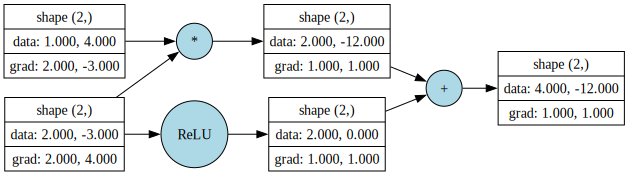

In [2]:
from opengrad import Tensor
from opengrad.viz import draw_graph

a = Tensor([2.0, -3.0])
b = Tensor([1.0, 4.0])
c = a * b + a.relu()

c.backward()

dot = draw_graph(c)
dot
# dot.render('my_graph')   # writes my_graph.svg

In [3]:
c.grad

array([1., 1.])

In [18]:
import torch
import numpy as np

# --- Our Tensor ---
a = Tensor([2.0, -3.0])
b = Tensor([1.0, 4.0])
c = a * b + a.relu()
c.backward()

# --- PyTorch ---
at = torch.tensor([2.0, -3.0], requires_grad=True)
bt = torch.tensor([1.0,  4.0], requires_grad=True)
ct = at * bt + at.relu()
ct.backward(torch.ones_like(ct))  # seed gradient as ones since ct is a vector

# --- Compare ---
print("        ours         torch")
print(f"a.grad  {a.grad}  {at.grad.numpy()}")
print(f"b.grad  {b.grad}  {bt.grad.numpy()}")

        ours         torch
a.grad  [2. 4.]  [2. 4.]
b.grad  [ 2. -3.]  [ 2. -3.]


In [4]:
a = Tensor([2.0, -3.0])
b = Tensor([1.0, 4.0])
c = Tensor([-2.0, 3.0])

d = a * b + c
e = d.tanh()

In [5]:
e**2

Tensor(shape=(2,), data=
[0.         0.99999994])

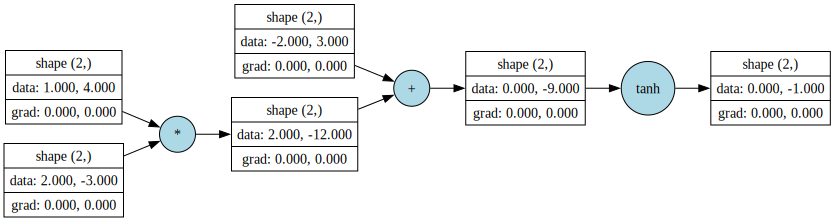

In [6]:
dot = draw_graph(e)
dot

In [7]:
e.backward()

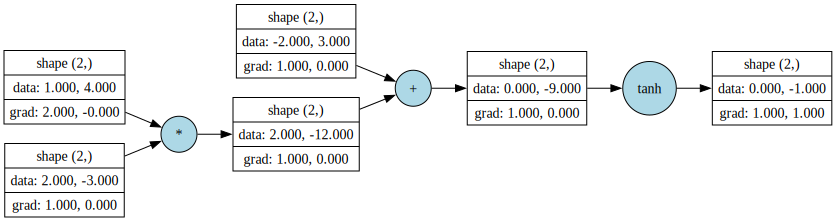

In [8]:
dot = draw_graph(e)
dot

In [9]:
1- e**2

Tensor(shape=(2,), data=
[1.00000000e+00 6.09199173e-08])

In [20]:
a = Tensor([[2.0, -3.0], [1.0, 3.0]])
b = Tensor([[1.0, 4.0], [2.5, 0.5]])
c = Tensor([[-2.0, 3.0], [-1, -2]])

d = a * b + c
e = d.tanh()

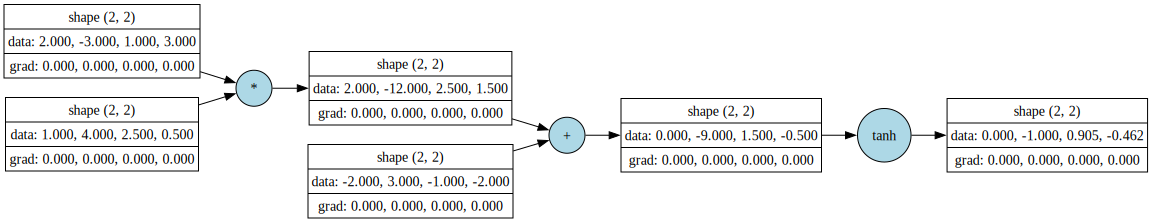

In [21]:
dot = draw_graph(e)
dot

In [22]:
e.backward()

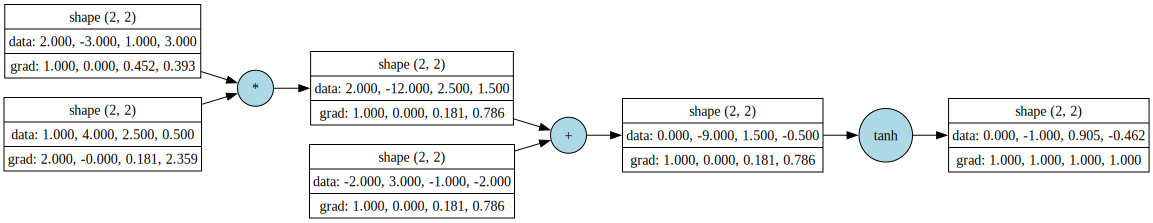

In [23]:
dot = draw_graph(e)
dot

In [24]:
# --- PyTorch ---
at = torch.tensor([[2.0, -3.0], [1.0, 3.0]], requires_grad=True)
bt = torch.tensor([[1.0,  4.0], [2.5, 0.5]], requires_grad=True)
ct = torch.tensor([[-2.0, 3.0], [-1.0, -2.0]], requires_grad=True)

dt = at * bt + ct
et = dt.tanh()
et.backward(torch.ones_like(et))

# --- Compare ---
print("         ours                    torch")
print(f"a.grad\n{a.grad}\n{at.grad.numpy()}\n")
print(f"b.grad\n{b.grad}\n{bt.grad.numpy()}\n")
print(f"c.grad\n{c.grad}\n{ct.grad.numpy()}\n")

         ours                    torch
a.grad
[[1.00000000e+00 2.43679669e-07]
 [4.51766597e-01 3.93223866e-01]]
[[1.0000000e+00 4.7683716e-07]
 [4.5176655e-01 3.9322385e-01]]

b.grad
[[ 2.00000000e+00 -1.82759752e-07]
 [ 1.80706639e-01  2.35934320e+00]]
[[ 2.0000000e+00 -3.5762787e-07]
 [ 1.8070662e-01  2.3593431e+00]]

c.grad
[[1.00000000e+00 6.09199173e-08]
 [1.80706639e-01 7.86447733e-01]]
[[1.0000000e+00 1.1920929e-07]
 [1.8070662e-01 7.8644770e-01]]



In [14]:
a

Tensor(shape=(2, 2), data=
[[ 2. -3.]
 [ 1.  3.]])

In [15]:
a + 1

Tensor(shape=(2, 2), data=
[[ 3. -2.]
 [ 2.  4.]])

In [16]:
dot.render('my_graph')

'my_graph.svg'

In [17]:
a * 2

Tensor(shape=(2, 2), data=
[[ 4. -6.]
 [ 2.  6.]])